### 4.1 LDA Topic Extraction

In [8]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim import corpora
from gensim.models import LdaModel
from gensim.parsing.preprocessing import STOPWORDS

corpus_dir = '../data/corpus'
files = sorted([f for f in os.listdir(corpus_dir) if f.endswith('.txt')])

STOP = set(stopwords.words('english')) | set(STOPWORDS)
LEM = WordNetLemmatizer()

def clean(text):
    # lowercase + remove non-letters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text.lower())
    tokens = word_tokenize(text)
    return [LEM.lemmatize(t) for t in tokens
            if t.isalpha() and t not in STOP and len(t) > 3]

docs_tokens = []
for fname in files:
    with open(os.path.join(corpus_dir, fname), encoding='utf-8') as f:
        docs_tokens.append(clean(f.read()))
    print(f"{fname} → {len(docs_tokens[-1])} tokens")

print(f"\nTokenized {len(docs_tokens)} documents")

research_1.txt → 2872 tokens
research_2.txt → 1170 tokens
research_3.txt → 1930 tokens
research_4.txt → 2911 tokens
research_5.txt → 2033 tokens

Tokenized 5 documents


In [3]:
# gensim dictionary and corpus
dictionary = corpora.Dictionary(docs_tokens)
dictionary.filter_extremes(no_below=2, no_above=0.9)

bow_corpus = [dictionary.doc2bow(doc) for doc in docs_tokens]

# LDA for 3 topics
N_TOPICS = 3
lda = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=N_TOPICS,
    random_state=42,
    passes=20,
    alpha='auto',
    per_word_topics=True
)

# print topics
print(f"LDA trained with {N_TOPICS} topics\n")
for i in range(N_TOPICS):
    words = lda.show_topic(i, topn=10)
    print(f"Topic {i+1}: " + ", ".join([w for w, _ in words]))

LDA trained with 3 topics

Topic 1: development, design, evaluation, model, product, term, orientation, specific, learning, problem
Topic 2: method, triangulation, mixed, quantitative, design, multiple, paradigm, reality, bias, position
Topic 3: alpha, cronbach, instrument, reliability, science, item, education, author, internal, student


#### LDA Topic Extraction

As shown above, LDA was trained with 3 topics on the 5 research abstracts. Three topics was chosen 
because the corpus is small and  too many topics would create overlapping, confusing 
clusters.

**Top keywords per topic:**

Topic 1: development, design, evaluation, model, product, term, orientation, specific, learning, problem.

Topic 2: method, triangulation, mixed, quantitative, design, multiple, paradigm, reality, bias, position.

Topic 3: alpha, cronbach, instrument, reliability, science, item, education, author, internal, student

**Suggested topics from keywords:**
- Topic 1 - Instructional Design
- Topic 2 - Mixed Methods Research
- Topic 3 - Psychometrics / Reliability

**Limitation:**
LDA works best with more than 20 documents. With only 5 documents, the topics are less stable 
and should be interpreted cautiously. These are suggested themes, not definitive labels.

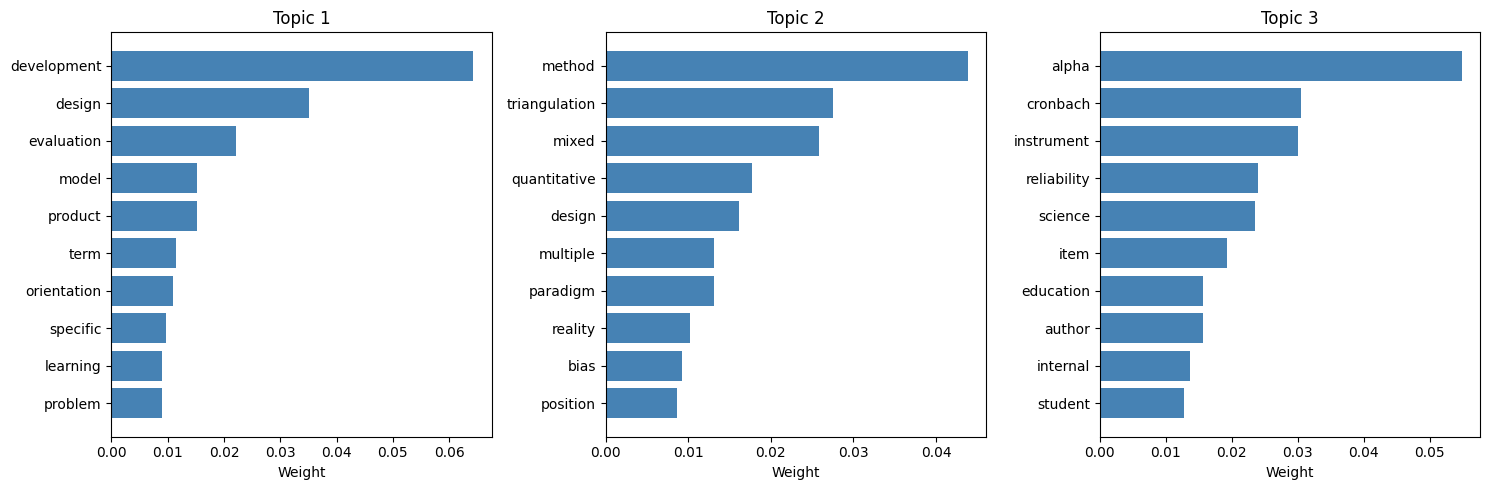

In [4]:
fig, axes = plt.subplots(1, N_TOPICS, figsize=(5 * N_TOPICS, 5))
for i, ax in enumerate(axes):
    words_probs = lda.show_topic(i, topn=10)
    words = [w for w, _ in words_probs]
    probs = [p for _, p in words_probs]

    ax.barh(words[::-1], probs[::-1], color='steelblue')
    ax.set_title(f"Topic {i+1}")
    ax.set_xlabel("Weight")

plt.tight_layout()
plt.savefig('../outputs/q4_topics.png', dpi=120)
plt.show()

### 4.2 pyLDAvis Interactive Map

In [12]:
import os
os.environ['JOBLIB_MULTIPROCESSING'] = '0'
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

lda_vis = pyLDAvis.gensim_models.prepare(lda, bow_corpus, dictionary, n_jobs=1)
pyLDAvis.display(lda_vis)

In [13]:
pyLDAvis.save_html(lda_vis, '../outputs/q4_pyldavis.html')
print("Saved: outputs/q4_pyldavis.html")

Saved: outputs/q4_pyldavis.html


#### pyLDAvis Interactive Topic Map

pyLDAvis generates an interactive HTML visualization that lets you explore topics 
by clicking and hovering. It shows how the topics relate to each other and which words define each topic. 
The file `q4_pyldavis.html` can be opened in any browser.

#### How to Use the Interactive Map
- **Click a button** on the left to select a topic
- **Read the bar chart** on the right to see that topic's top words
- **Drag the λ slider** to switch between frequency view and uniqueness view
- **Hover over any bar** to see the exact frequency value
- **Use Prev/Next buttons** to switch between topics

The left panel is the Intertopic Distance Map, where each circle represents one 
topic. As shown above , circle 1 is the largest, meaning it is the most common theme across all 
papers. Circle 2 sits alone on the left side, suggesting it is a more distinct 
topic. Circle 3 is the smallest, meaning it appears in fewer documents. The circles 
overlap slightly because the topics share vocabulary, which is expected with only 
5 documents.

The right panel shows the top terms for whichever topic is selected. Red bars show 
how often a word appears in that topic, while blue bars show how often it appears 
across all topics. Words like "alpha" and "cronbach" have long red bars but short 
blue bars, which makes them strong signals for Topic 2.

The overlap between circles happens because LDA needs many documents to cleanly 
separate topics. With only 5 papers that all discuss research methodology, the 
vocabulary is too similar to fully separate them. A larger corpus would spread 
the circles further apart.